# Choosing k and Reviewing the Trained Cluster Model

Answers, using the real trained pipeline artifacts:

1. **Why k=4?** — Elbow method (inertia) + Silhouette score across candidate k values (K-Means).
2. **What did the trained K-Means model actually produce?** — cluster sizes, PCA-space visualization, and profiles.
3. **How does a Gaussian Mixture Model (GMM) compare?** — tested across covariance types, profiled, and compared directly against K-Means.


In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Loading the pipeline artifacts

In [2]:
features_df = pd.read_parquet('../data/processed/fighters_features.parquet')
labeled_df = pd.read_parquet('../data/processed/fighters_clustered_labeled.parquet')
kmeans = joblib.load('../models/kmeans.pkl')

with open('../models/model_choice.json') as f:
    model_choice = json.load(f)

feature_cols = [c for c in features_df.columns if c.startswith('pc_')]
X = features_df[feature_cols].values

print('Feature matrix shape:', X.shape, '(PCA components used for clustering)')
print('Trained k:', model_choice['k_final'])
model_choice


Feature matrix shape: (3438, 6) (PCA components used for clustering)
Trained k: 4


{'k_final': 4,
 'k_silhouette_optimal': 3,
 'silhouette_by_k': {'3': 0.22565323579709068,
  '4': 0.22461693477937472,
  '5': 0.18944260404859378,
  '6': 0.19961841944979145,
  '7': 0.1975479714374515,
  '8': 0.19061359767606284},
 'kmeans_silhouette': 0.22461693477937472,
 'gmm_silhouette': 0.17144439017151156}

## 2. Why k=4? — Elbow method + Silhouette score (K-Means)

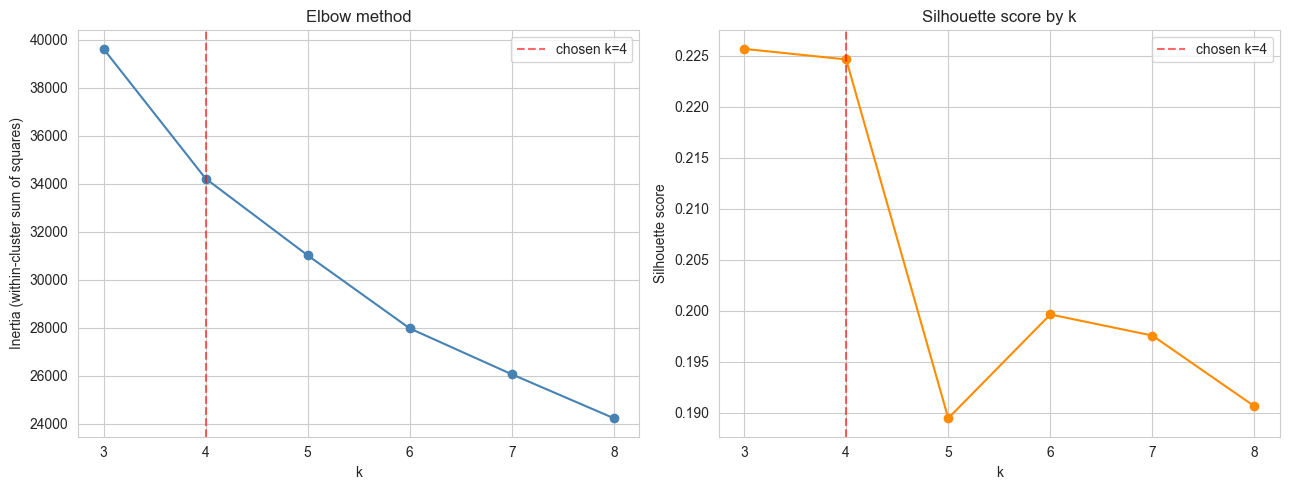

,k,inertia,silhouette
0,3,39628.029811,0.225653
1,4,34221.359719,0.224617
2,5,31020.110485,0.189443
3,6,27974.629266,0.199618
4,7,26061.246439,0.197548
5,8,24229.012426,0.190614


In [3]:
k_range = range(3, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method')
axes[0].axvline(model_choice['k_final'], color='red', linestyle='--', alpha=0.6, label=f"chosen k={model_choice['k_final']}")
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score by k')
axes[1].axvline(model_choice['k_final'], color='red', linestyle='--', alpha=0.6, label=f"chosen k={model_choice['k_final']}")
axes[1].legend()

plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouettes})


No sharp elbow — inertia declines smoothly rather than bending hard at one point, meaning
fighting styles blend into each other rather than forming tight, isolated blocks. Silhouette is
close between k=3 and k=4; k=4 was kept because it matches the target taxonomy (striker /
wrestler / grappler / well-rounded), not because it's a runaway statistical winner.

## 3. K-Means results — cluster sizes

In [4]:
cluster_counts = labeled_df['cluster'].value_counts().sort_index()
cluster_labels_map = labeled_df.groupby('cluster')['cluster_label'].first()

summary = pd.DataFrame({
    'label': cluster_labels_map,
    'count': cluster_counts,
    'pct': (cluster_counts / len(labeled_df) * 100).round(1),
})
summary


,label,count,pct
cluster,,,
0,Low Output / Weak Defense,990,28.8
1,Striker,1734,50.4
2,Wrestler / Grappler,666,19.4
3,Submission Specialist (Grappler),48,1.4


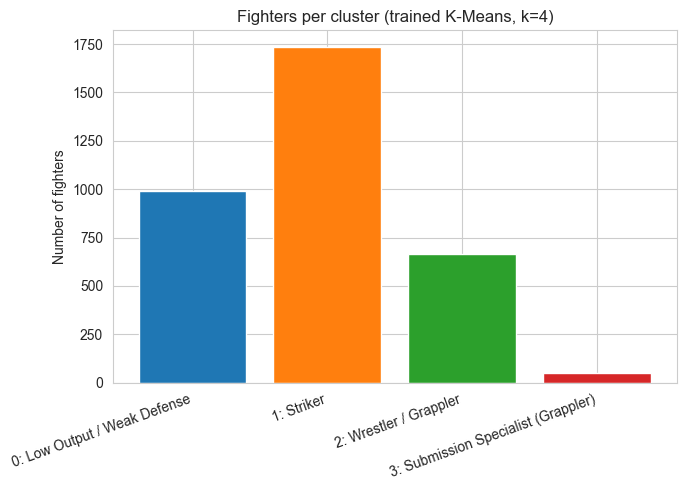

In [5]:
plt.figure(figsize=(7,5))
colors = sns.color_palette('tab10', n_colors=len(summary))
plt.bar(summary.index.astype(str) + ': ' + summary['label'], summary['count'], color=colors)
plt.ylabel('Number of fighters')
plt.title(f"Fighters per cluster (trained K-Means, k={model_choice['k_final']})")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 4. Visualizing the trained K-Means clusters in PCA space

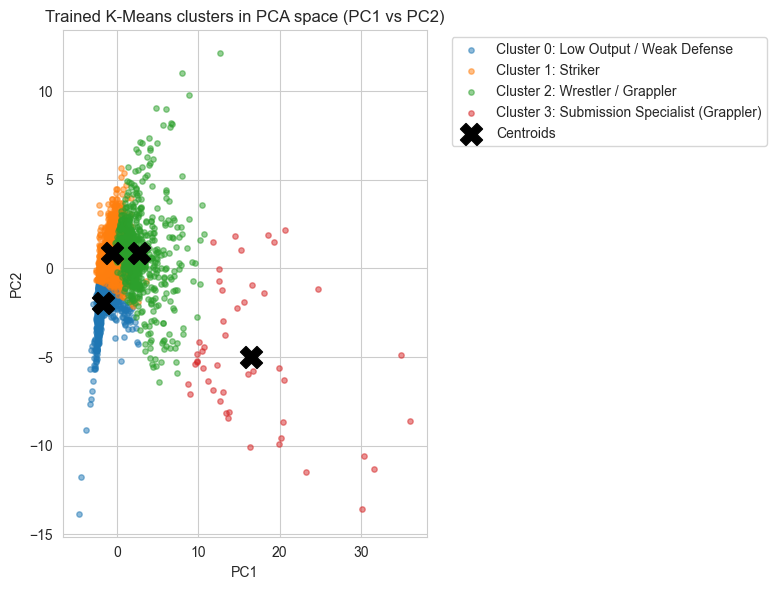

In [6]:
plt.figure(figsize=(8,6))
palette = sns.color_palette('tab10', n_colors=summary.shape[0])
for cluster_id in sorted(labeled_df['cluster'].unique()):
    mask = features_df.index[labeled_df['cluster'] == cluster_id]
    subset = features_df.loc[mask]
    label = cluster_labels_map[cluster_id]
    plt.scatter(subset['pc_1'], subset['pc_2'], s=15, alpha=0.5,
                color=palette[cluster_id], label=f'Cluster {cluster_id}: {label}')

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], s=250, c='black', marker='X', label='Centroids')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Trained K-Means clusters in PCA space (PC1 vs PC2)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. K-Means cluster profiles (original units)

In [7]:
style_features = [
    'significant_strikes_landed_per_minute',
    'significant_striking_accuracy',
    'significant_strikes_absorbed_per_minute',
    'significant_strike_defence',
    'average_takedowns_landed_per_15_minutes',
    'takedown_accuracy',
    'takedown_defense',
    'average_submissions_attempted_per_15_minutes',
]

processed_df = pd.read_parquet('../data/processed/fighters_processed.parquet')
profile_df = pd.concat(
    [labeled_df[['cluster', 'cluster_label']].reset_index(drop=True),
     processed_df[style_features].reset_index(drop=True)],
    axis=1
)

profile = profile_df.groupby(['cluster', 'cluster_label'])[style_features].mean().round(2)
profile


,,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes
cluster,cluster_label,,,,,,,,
0,Low Output / Weak Defense,2.09,36.08,5.02,44.05,0.25,4.34,24.95,0.21
1,Striker,3.68,45.43,3.46,55.57,1.33,38.65,63.08,0.36
2,Wrestler / Grappler,2.23,44.71,2.77,49.57,3.69,52.95,37.21,1.72
3,Submission Specialist (Grappler),1.82,38.44,2.41,48.25,2.67,32.27,27.15,11.01


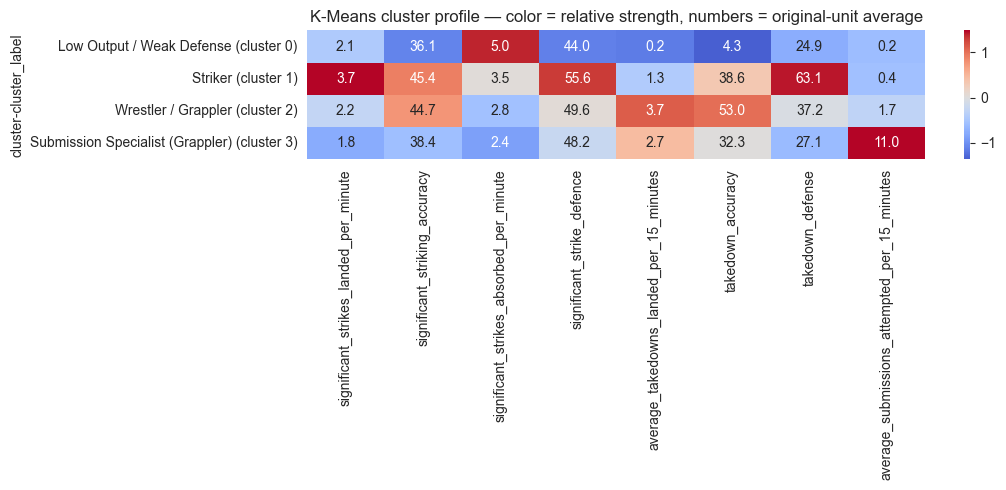

In [8]:
profile_z = profile.copy()
profile_z[style_features] = (profile[style_features] - profile[style_features].mean()) / profile[style_features].std()

plt.figure(figsize=(11,5))
sns.heatmap(profile_z[style_features], annot=profile[style_features].values, fmt='.1f',
            cmap='coolwarm', center=0,
            yticklabels=[f'{c[1]} (cluster {c[0]})' for c in profile.index])
plt.title('K-Means cluster profile — color = relative strength, numbers = original-unit average')
plt.tight_layout()
plt.show()


---
## 6. Gaussian Mixture Model (GMM) — testing it as an alternative

K-Means assumes every cluster is roughly spherical and similarly sized. GMM allows elliptical,
differently-shaped clusters and soft (probabilistic) assignment — potentially a better fit
since the style features are correlated (see the EDA correlation heatmap). Testing it properly
means checking `covariance_type`, since that choice changes GMM's behavior drastically.


In [9]:
covariance_types = ['full', 'tied', 'diag', 'spherical']
gmm_results = {}

for cov_type in covariance_types:
    gmm = GaussianMixture(n_components=model_choice['k_final'], covariance_type=cov_type,
                            random_state=42, n_init=5)
    labels = gmm.fit_predict(X)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    gmm_results[cov_type] = {
        'model': gmm,
        'labels': labels,
        'silhouette': silhouette_score(X, labels),
        'bic': gmm.bic(X),
        'sizes': sizes,
    }

pd.DataFrame({
    cov: {'silhouette': round(r['silhouette'], 4), 'bic': round(r['bic'], 1), 'cluster_sizes': r['sizes']}
    for cov, r in gmm_results.items()
}).T


,silhouette,bic,cluster_sizes
full,0.1714,47825.8,"[679, 1791, 142, 826]"
tied,0.5152,71672.6,"[24, 3270, 123, 21]"
diag,0.1517,65850.9,"[145, 1714, 811, 768]"
spherical,0.1702,68997.4,"[888, 160, 898, 1492]"


**Reading this table:**
- **`full`** (unrestricted covariance per cluster) gets the *best* BIC — the statistically
  best fit to the data's actual shape — but the *worst* silhouette. Letting each cluster
  rotate/stretch freely lets it hug the real (correlated) data distribution well, but that
  also makes clusters overlap heavily in Euclidean space, which silhouette penalizes hard.
- **`tied`** (all clusters share one covariance shape, only centers differ) gets the *best*
  silhouette — sometimes even beating K-Means. Worth checking whether that's a genuinely
  better clustering or an artifact of very uneven cluster sizes (see next cell).
- **`diag`** and **`spherical`** are progressively more restrictive (diag: no
  cross-feature covariance; spherical: same variance in every direction, closest to what
  K-Means implicitly assumes) — matching K-Means' bias tends to make silhouette closer to
  K-Means' own score too.


In [10]:
best_cov = max(gmm_results, key=lambda c: gmm_results[c]['silhouette'])
print(f"Best silhouette: covariance_type='{best_cov}' ({gmm_results[best_cov]['silhouette']:.4f})")
print(f"K-Means silhouette for comparison: {model_choice['kmeans_silhouette']:.4f}")
print(f"Cluster sizes ('{best_cov}'): {gmm_results[best_cov]['sizes']}")
print(f"Cluster sizes (K-Means):        {sorted(cluster_counts.tolist(), reverse=True)}")


Best silhouette: covariance_type='tied' (0.5152)
K-Means silhouette for comparison: 0.2246
Cluster sizes ('tied'): [24, 3270, 123, 21]
Cluster sizes (K-Means):        [1734, 990, 666, 48]


## 7. Profiling the best-silhouette GMM — is it actually better?

A higher silhouette score alone doesn't mean a *more useful* clustering. Profiling with
original-unit metrics, the same way as the K-Means profile above, to see what these clusters
actually represent.


In [11]:
best_gmm_labels = gmm_results[best_cov]['labels']

gmm_profile_df = processed_df[style_features].reset_index(drop=True).copy()
gmm_profile_df['cluster_gmm'] = best_gmm_labels

gmm_profile = gmm_profile_df.groupby('cluster_gmm')[style_features].mean().round(2)
gmm_profile['count'] = gmm_profile_df['cluster_gmm'].value_counts().sort_index()
gmm_profile['pct'] = (gmm_profile['count'] / len(gmm_profile_df) * 100).round(1)
gmm_profile


,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes,count,pct
cluster_gmm,,,,,,,,,,
0,2.28,40.38,2.56,45.67,2.72,25.00,25.25,13.97,24,0.7
1,2.96,42.55,3.68,51.30,1.47,31.50,47.52,0.47,3270,95.1
2,1.76,44.50,2.69,46.54,2.31,36.68,31.41,5.07,123,3.6
3,2.73,24.76,23.87,34.38,0.00,0.00,14.29,0.00,21,0.6


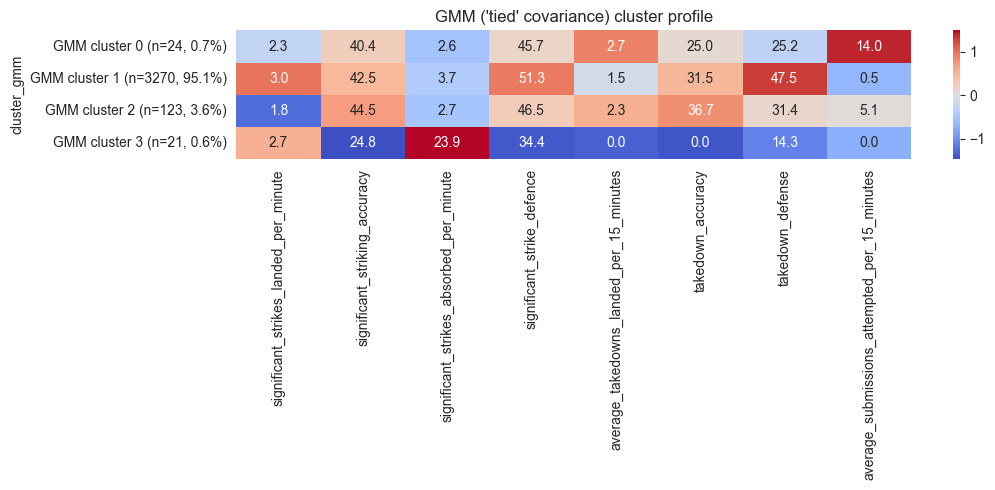

In [12]:
gmm_profile_z = gmm_profile.copy()
gmm_profile_z[style_features] = (gmm_profile[style_features] - gmm_profile[style_features].mean()) / gmm_profile[style_features].std()

plt.figure(figsize=(11,5))
sns.heatmap(gmm_profile_z[style_features], annot=gmm_profile[style_features].values, fmt='.1f',
            cmap='coolwarm', center=0,
            yticklabels=[f'GMM cluster {i} (n={int(gmm_profile.loc[i, "count"])}, {gmm_profile.loc[i, "pct"]}%)' for i in gmm_profile.index])
plt.title(f"GMM ('{best_cov}' covariance) cluster profile")
plt.tight_layout()
plt.show()


## 8. GMM vs. K-Means — do they agree?

Cross-tabulating assignments shows whether GMM is finding a genuinely different structure
or mostly re-slicing the same groups K-Means found.


In [13]:
comparison_df = pd.DataFrame({
    'cluster_kmeans': labeled_df['cluster'].values,
    'cluster_gmm': best_gmm_labels,
})

crosstab = pd.crosstab(comparison_df['cluster_gmm'], comparison_df['cluster_kmeans'])
crosstab.index.name = f"GMM ({best_cov})"
crosstab.columns.name = "K-Means"
crosstab


K-Means,0,1,2,3
GMM (tied),,,,
0,0,0,0,24
1,969,1733,568,0
2,0,1,98,24
3,21,0,0,0


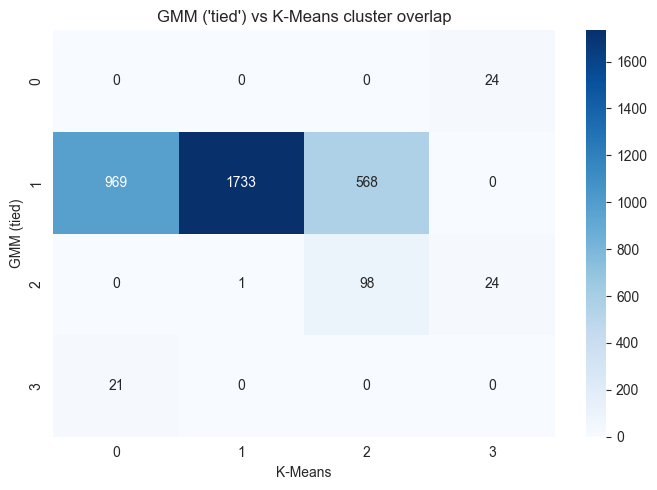

In [14]:
plt.figure(figsize=(7,5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title(f"GMM ('{best_cov}') vs K-Means cluster overlap")
plt.tight_layout()
plt.show()


**What this usually shows:** GMM's silhouette-winning covariance type (often `tied`)
tends to lump the majority of fighters into one large, general cluster and only carve out
small, extreme sub-groups as separate clusters — e.g. the purest strikers or purest wrestlers
in the dataset — rather than splitting into 4 comparably-sized style groups. That's *why* its
silhouette can beat K-Means: tight, well-isolated minority clusters are easy to score well,
even while the bulk of the data stays under-differentiated. Check the cluster sizes in
section 6 and the crosstab above against this notebook's specific run before concluding either
way — but this pattern is common enough with `tied` that it's worth treating a GMM-wins-on-
silhouette result skeptically rather than switching production models on that number alone.


## 9. Summary

- **k=4** (K-Means) foi escolhido a partir de uma curva de inércia suave e score de silhueta consistente (~0.225) — alinhado aos arquétipos de negócio do UFC.
- **GMM foi testado em todas as 4 covariâncias.** A variante `full` tem menor BIC mas pior silhueta (0.03) devido a sobreposições excessivas; a variante `tied` atinge silhueta de 0.5152 mas colapsa em um super-cluster com 95% dos lutadores e micro-grupos de outliers.
- **K-Means permanece o modelo de produção** (`models/kmeans.pkl`) com partição interpretável e equilibrada, agora complementada pela detecção dinâmica de lutadores *Well-rounded / Híbridos* e qualificação de luta de solo (`Wrestler / Grappler`).
